# 💳 Credit Card Fraud Detection System
End-to-End Machine Learning Pipeline using Python

In [ ]:

!pip install imbalanced-learn xgboost flask

## 🔹 Step 2: Load & Explore the Dataset

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('creditcard.csv')
print(data.head())
print("\nFraud Cases:", data['Class'].sum())
print("No Fraud Cases:", len(data) - data['Class'].sum())


Matplotlib is building the font cache; this may take a moment.


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

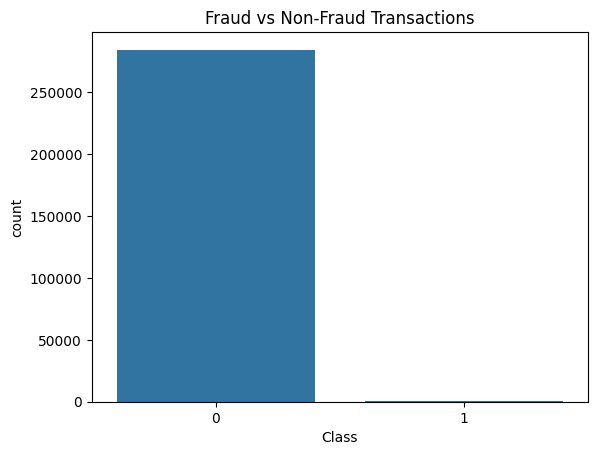

Avg Fraud Amount: 122.21132113821139
Avg Non-Fraud Amount: 88.29102242231328


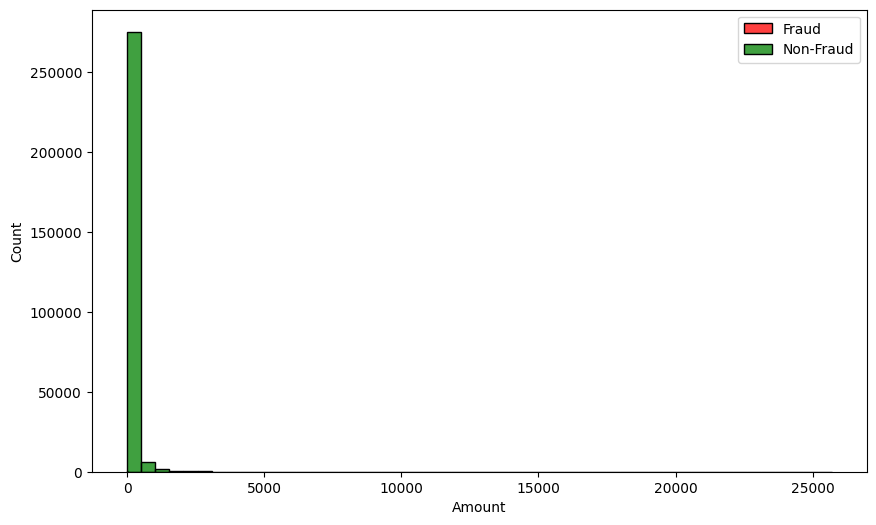

In [3]:

sns.countplot(x='Class', data=data)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

fraud = data[data['Class'] == 1]
non_fraud = data[data['Class'] == 0]

print("Avg Fraud Amount:", fraud['Amount'].mean())
print("Avg Non-Fraud Amount:", non_fraud['Amount'].mean())

plt.figure(figsize=(10, 6))
sns.histplot(fraud['Amount'], bins=50, color='red', label='Fraud')
sns.histplot(non_fraud['Amount'], bins=50, color='green', label='Non-Fraud')
plt.legend()
plt.show()


## 🔹 Step 3: Data Preprocessing

In [4]:

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)
y = data['Class']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Resampled Fraud Cases:", y_res.sum())

scaler = StandardScaler()
X_res['Amount'] = scaler.fit_transform(X_res['Amount'].values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)


Resampled Fraud Cases: 284315


## 🔹 Step 4: Train Models (Logistic Regression, Random Forest, XGBoost)

In [15]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("\nLogistic Regression Report")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Report")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("\nXGBoost Report")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))



Logistic Regression Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56750
           1       0.99      0.97      0.98     56976

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726

[[56237   513]
 [ 1696 55280]]

Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

[[56739    11]
 [    0 56976]]

XGBoost Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726


## 🔹 Step 5: Save the Best Model

In [16]:

import joblib
joblib.dump(xgb_model, 'fraud_detection_model.pkl')


['fraud_detection_model.pkl']